In [25]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch
import torch.nn
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()
train_dataset = datasets.mnist.MNIST(root='./data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.44MB/s]


In [3]:
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)

In [4]:
images, ytr = next(iter(train_loader))
images.shape

torch.Size([32, 1, 28, 28])

In [5]:
flat = images.view(-1, 28*28)
flat.shape

torch.Size([32, 784])

In [6]:
g = torch.Generator(device='cuda').manual_seed(42)  # Set generator to GPU
W1 = torch.randn((784, 128), generator=g, device='cuda') * 0.02  # Created on GPU
b1 = torch.zeros(128, device='cuda')                             # Created on GPU
W2 = torch.randn((128, 10), generator=g, device='cuda') * 0.01   # Created on GPU
b2 = torch.zeros(10, device='cuda')                              # Created on GPU
parameters = [W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
print(f"Total parameters to train: {sum(p.nelement() for p in parameters)}")

Total parameters to train: 101770


In [21]:
flat_cuda = flat.to('cuda')
ytr_cuda = ytr.to('cuda')
h = torch.tanh(flat_cuda @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ytr_cuda)
loss

tensor(2.3036, device='cuda:0', grad_fn=<NllLossBackward0>)

In [22]:
# 1. Create the DataLoader ONCE outside the loop so it reads your data sequentially
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)

# 2. Turn the loader into an active stream
data_iter = iter(train_loader)

for step in range(50000):
    # 3. Grab the NEXT sequential batch from the stream
    try:
        images, ytr = next(data_iter)
    except StopIteration:
        # If we read through all 60,000 images (1 epoch), refresh the stream and keep going
        data_iter = iter(train_loader)
        images, ytr = next(data_iter)

    # 4. Move inputs to GPU
    images = images.to('cuda')
    ytr = ytr.to('cuda')

    # 5. Flatten
    flat = images.view(-1, 28*28)

    # 6. Forward pass
    h = torch.tanh(flat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ytr)

    # 7. Reset gradient buffers
    for p in parameters:
        p.grad = None

    # 8. Backward pass
    loss.backward()

    # 9. Update step (Clean, explicit Gradient Descent)
    learning_rate = 0.1 # Bumped up slightly from 0.01 so it learns faster
    for p in parameters:
        p.data -= learning_rate * p.grad

    # 10. Print progress every 500 steps so you can watch the loss collapse!
    if step % 500 == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.4f}")

print(f"Final Step Loss: {loss.item():.4f}")

Step    0 | Loss: 2.3036
Step  500 | Loss: 0.2379
Step 1000 | Loss: 0.0856
Step 1500 | Loss: 0.1194
Step 2000 | Loss: 0.1529
Step 2500 | Loss: 0.1809
Step 3000 | Loss: 0.0935
Step 3500 | Loss: 0.1122
Step 4000 | Loss: 0.2100
Step 4500 | Loss: 0.0830
Step 5000 | Loss: 0.0462
Step 5500 | Loss: 0.0853
Step 6000 | Loss: 0.2765
Step 6500 | Loss: 0.0703
Step 7000 | Loss: 0.0219
Step 7500 | Loss: 0.0365
Step 8000 | Loss: 0.0750
Step 8500 | Loss: 0.0539
Step 9000 | Loss: 0.0206
Step 9500 | Loss: 0.0483
Step 10000 | Loss: 0.3644
Step 10500 | Loss: 0.0265
Step 11000 | Loss: 0.2318
Step 11500 | Loss: 0.0304
Step 12000 | Loss: 0.0049
Step 12500 | Loss: 0.0534
Step 13000 | Loss: 0.0234
Step 13500 | Loss: 0.1401
Step 14000 | Loss: 0.0299
Step 14500 | Loss: 0.0527
Step 15000 | Loss: 0.1040
Step 15500 | Loss: 0.0390
Step 16000 | Loss: 0.0287
Step 16500 | Loss: 0.1080
Step 17000 | Loss: 0.0026
Step 17500 | Loss: 0.0278
Step 18000 | Loss: 0.0351
Step 18500 | Loss: 0.0361
Step 19000 | Loss: 0.0372
Step 1

In [11]:
val_dataset = datasets.mnist.MNIST(
    root='./data',
    train=False,         # <--- Tells PyTorch to get the 10,000 test images
    download=True,
    transform=transform  # Uses the same ToTensor() transform you defined earlier
)

In [23]:
val_loader = DataLoader(dataset=val_dataset, batch_size=50, shuffle=False)
vimage , yvali = next(iter(val_loader))
vimage.shape
flat_vali = vimage.view(-1,28*28)
flat_val = flat_vali.to('cuda')
y_val = yvali.to('cuda')

In [24]:
h = torch.tanh(flat_val @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y_val)
loss

tensor(0.0173, device='cuda:0', grad_fn=<NllLossBackward0>)

PyTorch Shape: torch.Size([1, 28, 28])
Adjusted Shape for Plotting: torch.Size([28, 28])


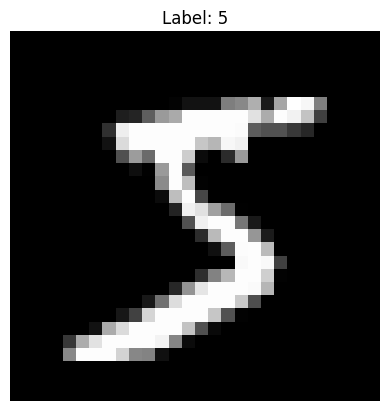

In [26]:
sample_image, sample_label = train_dataset[0]
print("PyTorch Shape:", sample_image.shape) # Output: torch.Size([1, 28, 28])
display_image = sample_image.squeeze()
print("Adjusted Shape for Plotting:", display_image.shape)
plt.imshow(display_image, cmap='gray')
plt.title(f"Label: {sample_label}")
plt.axis('off') # Hide the x and y axis pixel numbers
plt.show()

In [32]:
# 1. Pick any image index from the dataset (e.g., index 0)
image_index = 600
sample_image, sample_label = train_dataset[image_index]


sample_flat = sample_image.view(1, 28*28)

# 3. Move the flattened image tensor to your GPU
sample_flat = sample_flat.to('cuda')

# 4. Run the forward pass (wrapped in no_grad because we are just evaluating)
with torch.no_grad():
    h = torch.tanh(sample_flat @ W1 + b1)
    logits = h @ W2 + b2


    probabilities = F.softmax(logits, dim=1)

    confidence, prediction = torch.max(probabilities, dim=1)

# 5. Print the results to see if the model got it right!
print(f"--- SINGLE IMAGE TEST ---")
print(f"Ground Truth Label : {sample_label}")
print(f"Model Prediction   : {prediction.item()}")
print(f"Model Confidence   : {confidence.item() * 100:.2f}%")

--- SINGLE IMAGE TEST ---
Ground Truth Label : 9
Model Prediction   : 9
Model Confidence   : 100.00%


In [33]:
import torch

# 1. Pack all trained parameters and configuration metadata into a dictionary
full_model_state = {
    'W1': W1,
    'b1': b1,
    'W2': W2,
    'b2': b2,
    'parameters_requires_grad': [p.requires_grad for p in parameters]
}

# 2. Define your file name
checkpoint_name = 'scratch_mlp_mnist_full.pt'

# 3. Save the dictionary to disk
torch.save(full_model_state, checkpoint_name)

print(f"Successfully saved the entire model state to '{checkpoint_name}'!")

Successfully saved the entire model state to 'scratch_mlp_mnist_full.pt'!


In [34]:
from google.colab import files

# This initiates a physical file download to your computer
files.download(checkpoint_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>